# DBSCAN Clustering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

In [3]:
df=pd.read_csv('Data/Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
X=df.iloc[:,[3,4]].values

In [5]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [7]:
eps_values = np.arange(0.2, 1.2, 0.1)
min_samples_values = range(3, 10)
best_eps, best_min_samples, best_silhouette = None, None, -1

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters > 1:  # Hitung silhouette score jika minimal ada 2 cluster
            filtered_labels = labels[labels != -1]
            filtered_data = X_scaled[labels != -1]
            sil_score = silhouette_score(filtered_data, filtered_labels)
            if sil_score > best_silhouette:
                best_eps, best_min_samples, best_silhouette = eps, min_samples, sil_score

# Train DBSCAN dengan parameter terbaik
dbscan_best = DBSCAN(eps=best_eps, min_samples=best_min_samples)
dbscan_labels = dbscan_best.fit_predict(X_scaled)

# ============== K-MEANS OPTIMIZATION ==================
distortions, silhouette_scores = [], []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    distortions.append(sum(np.min(cdist(X_scaled, kmeans.cluster_centers_, 'euclidean'), axis=1)) / X_scaled.shape[0])
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Menentukan K optimal berdasarkan Elbow Method
best_k = K_range[np.argmax(silhouette_scores)]

# Train K-Means dengan jumlah cluster terbaik
kmeans_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans_best.fit_predict(X_scaled)

=== DBSCAN RESULTS ===
Best Epsilon: 0.30000000000000004
Best Min Samples: 7
Best Silhouette Score: 0.6452
Number of Clusters (DBSCAN): 4

=== K-MEANS RESULTS ===
Optimal Number of Clusters (Elbow Method): 5
Silhouette Score (K-Means): 0.5547


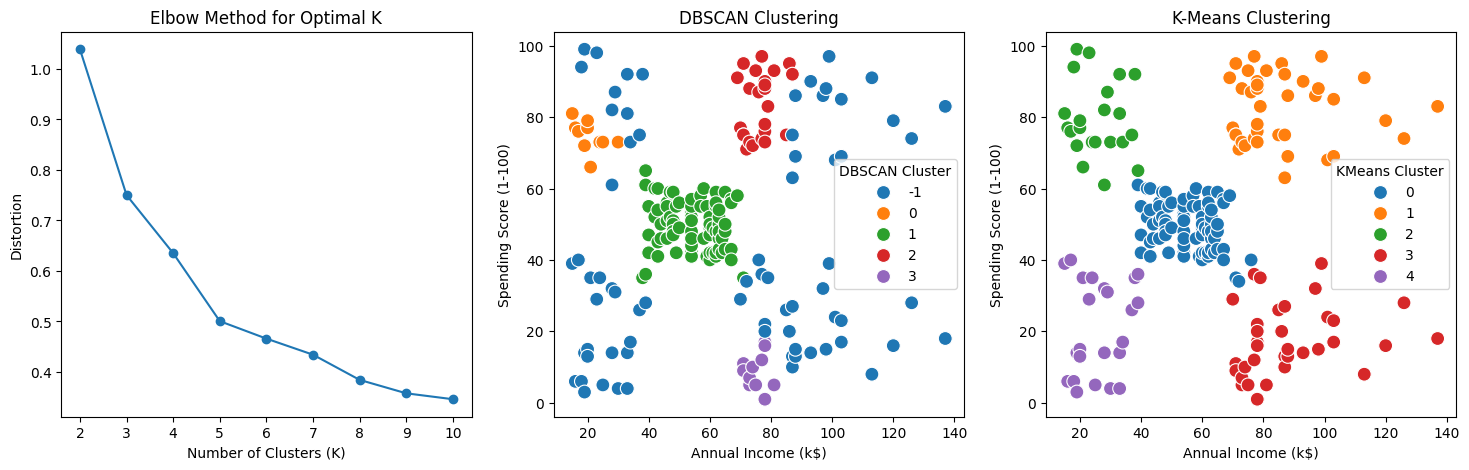

In [8]:
# ============== PRINT HASIL ANALISIS ===================
print("=== DBSCAN RESULTS ===")
print(f"Best Epsilon: {best_eps}")
print(f"Best Min Samples: {best_min_samples}")
print(f"Best Silhouette Score: {best_silhouette:.4f}")
print(f"Number of Clusters (DBSCAN): {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)}")

print("\n=== K-MEANS RESULTS ===")
print(f"Optimal Number of Clusters (Elbow Method): {best_k}")
print(f"Silhouette Score (K-Means): {max(silhouette_scores):.4f}")

# ============== VISUALIZATION ===================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Elbow Method plot
axes[0].plot(K_range, distortions, marker='o')
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Distortion")
axes[0].set_title("Elbow Method for Optimal K")

# DBSCAN plot
df["DBSCAN Cluster"] = dbscan_labels
sns.scatterplot(x=df["Annual Income (k$)"], y=df["Spending Score (1-100)"],
                hue=df["DBSCAN Cluster"], palette="tab10", s=100, ax=axes[1])
axes[1].set_title("DBSCAN Clustering")
axes[1].set_xlabel("Annual Income (k$)")
axes[1].set_ylabel("Spending Score (1-100)")

# K-Means plot
df["KMeans Cluster"] = kmeans_labels
sns.scatterplot(x=df["Annual Income (k$)"], y=df["Spending Score (1-100)"],
                hue=df["KMeans Cluster"], palette="tab10", s=100, ax=axes[2])
axes[2].set_title("K-Means Clustering")
axes[2].set_xlabel("Annual Income (k$)")
axes[2].set_ylabel("Spending Score (1-100)")

plt.show()
